# Sobel Filter

(a)Sobel filer using filter2D

In [18]:
# import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread('jeniffer.jpg', cv2.IMREAD_REDUCED_GRAYSCALE_2)



filter2D

In [37]:
# Define the kernel for averaging
kernel = np.ones((12, 12), np.float32) / 144
# Apply filter2D to the image
image_averaged = cv2.filter2D(image, cv2.CV_32F, kernel)

plot and compare

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

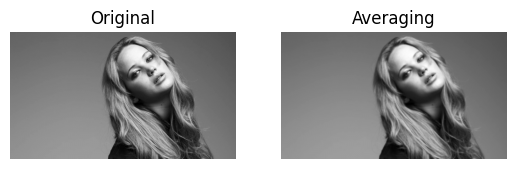

In [36]:

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(image_averaged, cmap='gray')
plt.title('Averaging')
plt.axis('off')

(b)Custom Sobel Filter

In [20]:
pip install scipy

  Using cached scipy-1.16.1-cp311-cp311-win_amd64.whl (38.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import math

# Load image in grayscale
image = cv2.imread('jeniffer.jpg', cv2.IMREAD_REDUCED_GRAYSCALE_2)



Kernal Generator

In [49]:
def sobel_kernel(size):
    if size % 2 == 0 or size < 3:
        raise ValueError("Size must be an odd integer ≥ 3")

    # Generate smoothing vector from Pascal's triangle
    smoothing = np.array([math.comb(size - 1, i) for i in range(size)], dtype=np.float32)

    # Derivative vector (central difference)
    derivative = np.zeros(size, dtype=np.float32)
    mid = size // 2
    for i in range(size):
        derivative[i] = i - mid

    # Normalize derivative to match Sobel scale 
    derivative = derivative / np.sum(np.abs(derivative[mid-1:mid+2]))

    # Create kernels using outer products
    Gx = np.outer(smoothing, derivative)
    Gy = np.outer(derivative, smoothing)

    return Gx, Gy

Define Sobel Filter

In [50]:

# Horizontal edge detection (Gx) and Vertical edge detection (Gy)
Gx, Gy = sobel_kernel(9)

# Convolve manually
sobel_x = convolve2d(image, Gx, mode='same', boundary='symm')
sobel_y = convolve2d(image, Gy, mode='same', boundary='symm')

# Gradient magnitude
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

Display

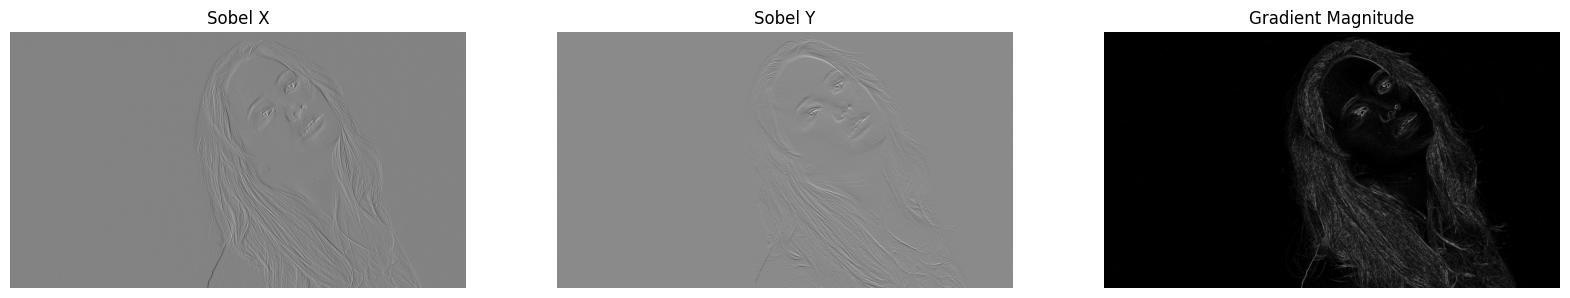

In [33]:
plt.figure(figsize=(20,8))

plt.subplot(1,3,1)
plt.imshow(sobel_x, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobel_y, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.show()

Get the avergae image

In [67]:
# Get image dimensions
rows, cols = image.shape
kernel_size = 9
pad = kernel_size // 2

# Pad the image to handle edges
padded_image = np.pad(image, pad, mode='constant', constant_values=0)

# Create an empty output image
image_avg = np.zeros_like(image, dtype=np.float32)

# Apply manual averaging
for i in range(rows):
    for j in range(cols):
        window = padded_image[i:i+kernel_size, j:j+kernel_size]
        image_avg[i, j] = np.mean(window)

# Convert back to uint8 for display
image_avg = np.uint8(image_avg)

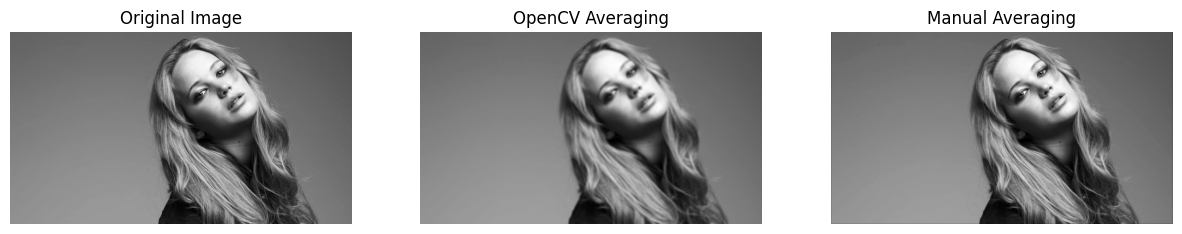

In [68]:
plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(image_averaged, cmap='gray')
plt.title('OpenCV Averaging')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(image_avg, cmap='gray')
plt.title('Manual Averaging')
plt.axis('off')

plt.show()


(c)Using 1D matrix

In [ ]:
# X kernels
vertical_sobel = np.array([[1], [2], [1]], dtype=np.float32)       # smoothing vertically
horizontal_sobel_x = np.array([[1, 0, -1]], dtype=np.float32)      # derivative horizontally

# Sobel X filtering: vertical then horizontal
temp_x = convolve2d(image, vertical_sobel, mode='same', boundary='symm')
sobel_x = convolve2d(temp_x, horizontal_sobel_x, mode='same', boundary='symm')

#Y kernels
horizontal_sobel = np.array([[1, 2, 1]], dtype=np.float32)         # smoothing horizontally
vertical_sobel_y = np.array([[1], [0], [-1]], dtype=np.float32)    # derivative vertically

# Sobel Y filtering: horizontal then vertical
temp_y = convolve2d(image, horizontal_sobel, mode='same', boundary='symm')
sobel_y = convolve2d(temp_y, vertical_sobel_y, mode='same', boundary='symm')

#Gradient magnitude
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)





Display

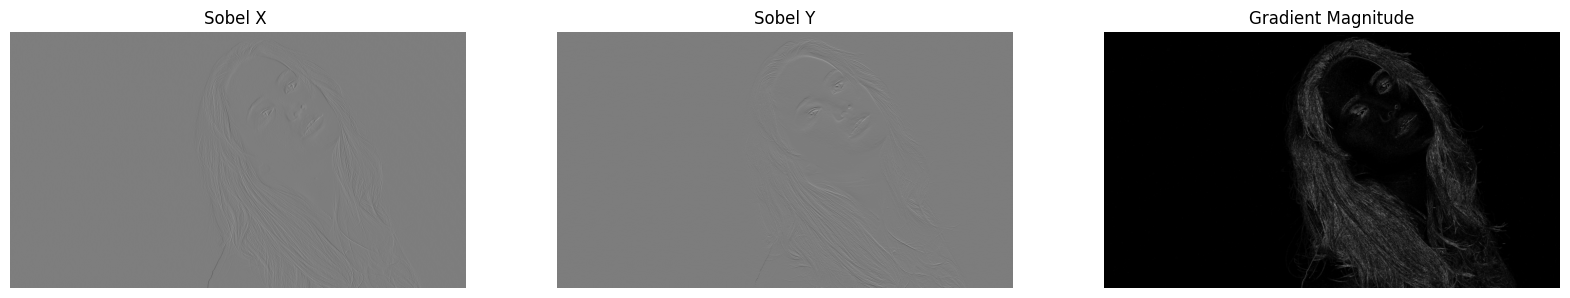

In [65]:
plt.figure(figsize=(20,8))

plt.subplot(1,3,1)
plt.imshow(sobel_x, cmap='gray')
plt.title('Sobel X ')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobel_y, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.show()

comapre with original image

In [ ]:
# smoothing kernels
vertical_avg = np.array([[1], [2], [1]], dtype=np.float32)
horizontal_avg = np.array([[1, 2, 1]], dtype=np.float32)
vertical_avg /= vertical_avg.sum()
horizontal_avg /= horizontal_avg.sum()

# Averaging filtering: vertical then horizontal
temp_avg = convolve2d(image, vertical_avg, mode='same', boundary='symm')
avg_filtered = convolve2d(temp_avg, horizontal_avg, mode='same', boundary='symm')

(np.float64(-0.5), np.float64(3839.5), np.float64(2159.5), np.float64(-0.5))

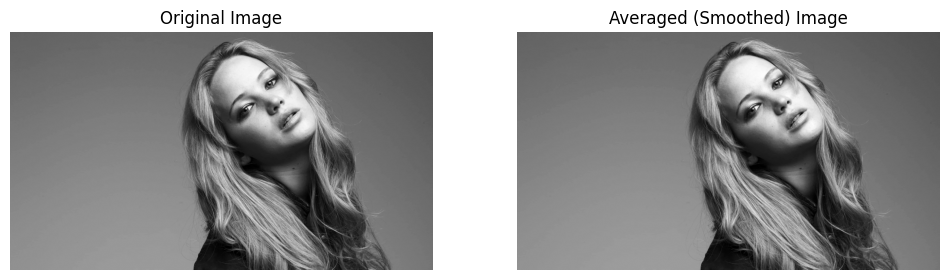

In [63]:

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(avg_filtered, cmap='gray')
plt.title('Averaged (Smoothed) Image')
plt.axis('off')
